In [5]:
#第一题
import numpy as np
import json

class FaceFeatDetect:
    def __init__(self,path,feat_path):
        self.target_feat = self.load_target_feat(path)
        self.names ,self.feats = self.load_feats(feat_path)
    
    def load_target_feat(self,path):
        with open(path,'r',encoding = 'utf-8') as file:
            line = file.readline()
            tgt_lst = json.loads(line)
        return np.array(tgt_lst)
    
    def load_feats(self,path):
        with open(path,'r',encoding = 'utf-8') as file:
            lines = file.readlines()
        
        names = []
        feats = []
        for line in lines:
            infos = line.strip().split("|")
            name = infos[1]                
            feat_lst = json.loads(infos[2])
            names.append(name)
            feats.append(feat_lst)
        return names, np.array(feats)
    
    def call_similarity(self,top_k=3):
        dists = np.linalg.norm(self.feats - self.target_feat, axis=1)
        idx = np.argsort(dists)
        
        print(f"🔝 前{top_k}个最相似特征（欧氏距离）:")
        print(f"{'排名':<6}{'姓名':<10}{'距离':<12}{'原索引'}")
        
        for rank, i in enumerate(idx[:top_k], 1):
            print(f"{rank:<6}{self.names[i]:<10}{dists[i]:.6f}    (id={i})")

if __name__ == "__main__":
    path = "files/No1/target_feat.txt"
    feat_path = "files/No1/feat.txt"
    
    face = FaceFeatDetect(path, feat_path)
    print(f"目标特征维度: {face.target_feat.shape}")
    print(f"特征库总数: {len(face.names)}")
    face.call_similarity(top_k=3)

目标特征维度: (128,)
特征库总数: 11
🔝 前3个最相似特征（欧氏距离）:
排名    姓名        距离          原索引
1     XY        0.000000    (id=10)
2     XY        0.661405    (id=9)
3     XY        0.734417    (id=8)


In [ ]:
#第二题
import os
import xml.etree.ElementTree as ET

voc_path = "files/No2/VOC2007"
ann_dir = os.path.join(voc_path, "Annotations")
img_dir = os.path.join(voc_path, "JPEGImages")
output_file = "results.txt"

all_classes = set()
xml_files = [f for f in os.listdir(ann_dir) if f.endswith(".xml")]
xml_files.sort()

for xml_file in xml_files:
    tree = ET.parse(os.path.join(ann_dir, xml_file))
    root = tree.getroot()
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        all_classes.add(class_name)

all_classes = sorted(all_classes)
class_to_id = {name: idx for idx, name in enumerate(all_classes)}

print("=" * 50)
print("所有类别名称及编号:")
print(f"{'编号':<6}{'类别名称'}")
print("-" * 30)
for name, idx in class_to_id.items():
    print(f"{idx:<6}{name}")
print("=" * 50)

with open(output_file, "w", encoding="utf-8") as f:
    for xml_file in xml_files:
        tree = ET.parse(os.path.join(ann_dir, xml_file))
        root = tree.getroot()
        
        filename = root.find("filename").text
        img_path = os.path.join(img_dir, filename)
        
        line_parts = [img_path]
        
        for obj in root.findall("object"):
            class_name = obj.find("name").text
            class_id = class_to_id[class_name]
            
            bndbox = obj.find("bndbox")
            xmin = int(bndbox.find("xmin").text)
            ymin = int(bndbox.find("ymin").text)
            xmax = int(bndbox.find("xmax").text)
            ymax = int(bndbox.find("ymax").text)
            
            center_x = (xmin + xmax) / 2
            center_y = (ymin + ymax) / 2
            w = xmax - xmin
            h = ymax - ymin
            
            line_parts.extend([str(class_id), f"{center_x:.1f}", f"{center_y:.1f}", str(w), str(h)])
        
        f.write(" ".join(line_parts) + "\n")

print(f"\n已生成 {output_file}")



所有类别名称及编号:
编号    类别名称
------------------------------
0     cat
1     chair
2     cow
3     diningtable
4     dog
5     person
6     pottedplant
7     train

已生成 results.txt


In [27]:
#第三题
import numpy as np

def compute_iou(box, boxes):
    x1_int = np.maximum(box[0],boxes[:,0])
    y1_int = np.maximum(box[1],boxes[:,1])
    x2_int = np.minimum(box[2],boxes[:,2])
    y2_int = np.minimum(box[3],boxes[:,3])
    
    int_w = np.maximum(0,x2_int - x1_int)
    int_h = np.maximum(0,y2_int - y1_int)
    int_area = int_w * int_h
    
    box_area = (box[2] - box[0]) * (box[3] - box[1])
    boxes_area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    union_area = box_area + boxes_area - int_area
    
    iou = np.where(union_area > 0, int_area / union_area, 0.0)
    return iou
    
box = np.array([20, 20, 60, 60])
boxes = np.array([[30, 30, 70, 70],
                  [30, 30, 50, 50],
                  [70, 70, 90, 90],
                  [60, 20, 80, 60]])

ious = compute_iou(box, boxes)
for i, iou in enumerate(ious):
    print(f"boxes[{i}] 的 IOU = {iou:.4f}")

boxes[0] 的 IOU = 0.3913
boxes[1] 的 IOU = 0.2500
boxes[2] 的 IOU = 0.0000
boxes[3] 的 IOU = 0.0000


In [ ]:
#第四题 图片缩放
import cv2

img = cv2.imread("gradient.png")
print(f"原图尺寸: {img.shape}")  # (H, W, C)

img_resized = cv2.resize(img, (416, 416))

cv2.imwrite("gradient_resized_416x416.png", img_resized)
print(f"缩放后尺寸: {img_resized.shape}")
print("已保存为 gradient_resized_416x416.png")

原图尺寸: (255, 255, 3)
缩放后尺寸: (416, 416, 3)
已保存为 gradient_resized_416x416.png


首字母 'Q' 的 ASCII 码: 81 (奇数) → 选择: 1.jpg
原图尺寸: 638x562
  piece_1.png 尺寸: 319x281
  piece_2.png 尺寸: 319x281
  piece_3.png 尺寸: 319x281
  piece_4.png 尺寸: 319x281
合并后尺寸: 638x562, 与原图一致: True

已保存: piece_1~4.png, merged.png, result_with_text.png


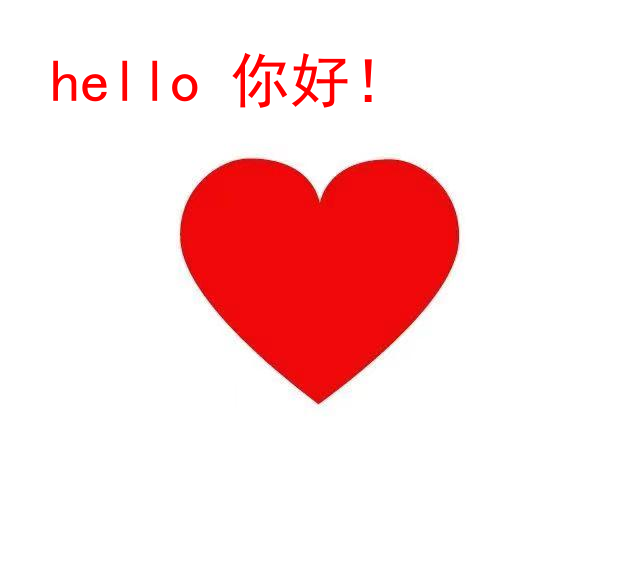

In [ ]:
#第五题
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont

# 1) 输入姓首字母大写，获取 ASCII 码，选图
first_letter = 'Q'  
ascii_code = ord(first_letter)
img_name = "1.jpg" if ascii_code % 2 == 1 else "2.jpg"
print(f"首字母 '{first_letter}' 的 ASCII 码: {ascii_code} ({'奇数' if ascii_code % 2 == 1 else '偶数'}) → 选择: {img_name}")

# 2) 读取图片
img = cv2.imread(f"files/No5/{img_name}")
if img is None:
    raise FileNotFoundError(f"无法读取 files/No5/{img_name}")
h, w = img.shape[:2]
print(f"原图尺寸: {w}x{h}")

# 3) 将图片切割成 4 张小图片并保存
h_mid, w_mid = h // 2, w // 2
pieces = [
    img[0:h_mid, 0:w_mid],       # 左上
    img[0:h_mid, w_mid:w],       # 右上
    img[h_mid:h, 0:w_mid],       # 左下
    img[h_mid:h, w_mid:w]        # 右下
]
for i, piece in enumerate(pieces, 1):
    cv2.imwrite(f"piece_{i}.png", piece)
    print(f"  piece_{i}.png 尺寸: {piece.shape[1]}x{piece.shape[0]}")

# 4) 将 4 张小图片合并成完整图片
top = np.hstack((pieces[0], pieces[1]))
bottom = np.hstack((pieces[2], pieces[3]))
merged = np.vstack((top, bottom))
cv2.imwrite("merged.png", merged)
print(f"合并后尺寸: {merged.shape[1]}x{merged.shape[0]}, 与原图一致: {np.array_equal(merged, img)}")

# 5) 在图片上显示文字 "hello 你好！"
img_rgb = cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(img_rgb)
draw = ImageDraw.Draw(pil_img)

# 尝试加载中文字体，找不到则用默认字体
try:
    font = ImageFont.truetype("simhei.ttf", 60)
except Exception:
    try:
        font = ImageFont.truetype("C:/Windows/Fonts/simhei.ttf", 60)
    except Exception:
        font = ImageFont.load_default()

draw.text((50, 50), "hello 你好！", fill=(255, 0, 0), font=font)

result = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
cv2.imwrite("result_with_text.png", result)
print("\n已保存: piece_1~4.png, merged.png, result_with_text.png")

display(Image.fromarray(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)))